In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

In [8]:
df = pd.read_csv('Ordenacao_Crescente.csv', encoding='latin1', sep=';')


def parse_br(series):
    return pd.to_numeric(
        series.astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )


In [6]:

# Converter coluna de tamanho de entrada
df['Tamanho de Entrada'] = parse_br(df['Tamanho de Entrada'])

# Converter todas as colunas de algoritmos
df['Bolha Inteligente'] = parse_br(df['Bolha Inteligente'])
df['Selecao']           = parse_br(df['Selecao'])
df['Insercao']          = parse_br(df['Insercao'])
df['MergeSort']         = parse_br(df['MergeSort'])
df['QuickSort Trad.']   = parse_br(df['QuickSort Trad.'])
df['ShellSort']         = parse_br(df['ShellSort'])
df['HeapSort']          = parse_br(df['HeapSort'])


# Filtrar cada algoritmo pelas linhas onde ELE tem dado
def get_xy(coluna):
    sub = df[['Tamanho de Entrada', coluna]].dropna()
    return sub['Tamanho de Entrada'].values, sub[coluna].values

x1, y1 = get_xy('Bolha Inteligente')
x2, y2 = get_xy('Selecao')
x3, y3 = get_xy('Insercao')
x4, y4 = get_xy('MergeSort')
x5, y5 = get_xy('QuickSort Trad.')
x6, y6 = get_xy('ShellSort')
x7, y7 = get_xy('HeapSort')

sns.set_style('darkgrid')
plt.figure(figsize=(15, 8))

plt.plot(x1, y1, marker='o', color='#FF6B6B', linewidth=2.5, markersize=8, label='Bolha Inteligente')
plt.plot(x2, y2, marker='o', color='#4ECDC4',    linewidth=2.5, markersize=8, label='Selecao')
plt.plot(x3, y3, marker='o', color='#45B7D1',     linewidth=2.5, markersize=8, label='Insercao')
plt.plot(x4, y4, marker='o', color='#FFA07A',       linewidth=2.5, markersize=8, label='MergeSort')
plt.plot(x5, y5, marker='o', color='#98D8C8',    linewidth=2.5, markersize=8, label='QuickSort Trad.')
plt.plot(x6, y6, marker='o', color='#F7DC6F',     linewidth=2.5, markersize=8, label='ShellSort')
plt.plot(x7, y7, marker='o', color='#BB8FCE',      linewidth=2.5, markersize=8, label='HeapSort')

plt.xscale('log')
plt.yscale('log')

todos_x = sorted(df['Tamanho de Entrada'].dropna().unique())
plt.xticks(todos_x, labels=[f'{int(v):,}'.replace(',', '.') for v in todos_x], rotation=45)

plt.title('Média de Movimentações - Função Ordem Drescente', fontsize=14, fontweight='bold')
plt.xlabel('Tamanho de entrada (n)', fontsize=12)
plt.ylabel('Movimentações ', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.show()

KeyError: 'Bolha Inteligente'

In [ ]:
# Criar 3 datasets: um para Tempo, outro para Comparações e outro para Movimentações
# Dataset de Tempo (Temp)
df_tempo = df[['Tamanho de Entrada'] + [col for col in df.columns if col.startswith('Temp')]].copy()

# Dataset de Comparações (Comp)
df_comparacoes = df[['Tamanho de Entrada'] + [col for col in df.columns if col.startswith('Comp')]].copy()

# Dataset de Movimentações (Mov)
df_movimentacoes = df[['Tamanho de Entrada'] + [col for col in df.columns if col.startswith('Mov')]].copy()

print("Dataset Tempo:")
print(df_tempo)
print("\nDataset Comparações:")
print(df_comparacoes)
print("\nDataset Movimentações:")
print(df_movimentacoes)

Dataset Tempo:
   Tamanho de Entrada  TempMergeSort  TempShellSort  TempHeapSort
0              1000.0            0.0            0.0           0.0
1             10000.0            1.0            0.0           1.0
2            100000.0            9.0            9.0          14.0
3           1000000.0          132.0           53.0         145.0
4          10000000.0         1482.0          518.0        1522.0
5                 NaN            NaN            NaN           NaN
6                 NaN            NaN            NaN           NaN
7                 NaN            NaN            NaN           NaN
8                 NaN            NaN            NaN           NaN
9                 NaN            NaN            NaN           NaN

Dataset Comparações:
   Tamanho de Entrada  CompMergeSort  CompShellSort  CompHeapSort
0              1000.0         5044.0         8006.0       17544.0
1             10000.0        69008.0       120005.0      244418.0
2            100000.0       853904.0   

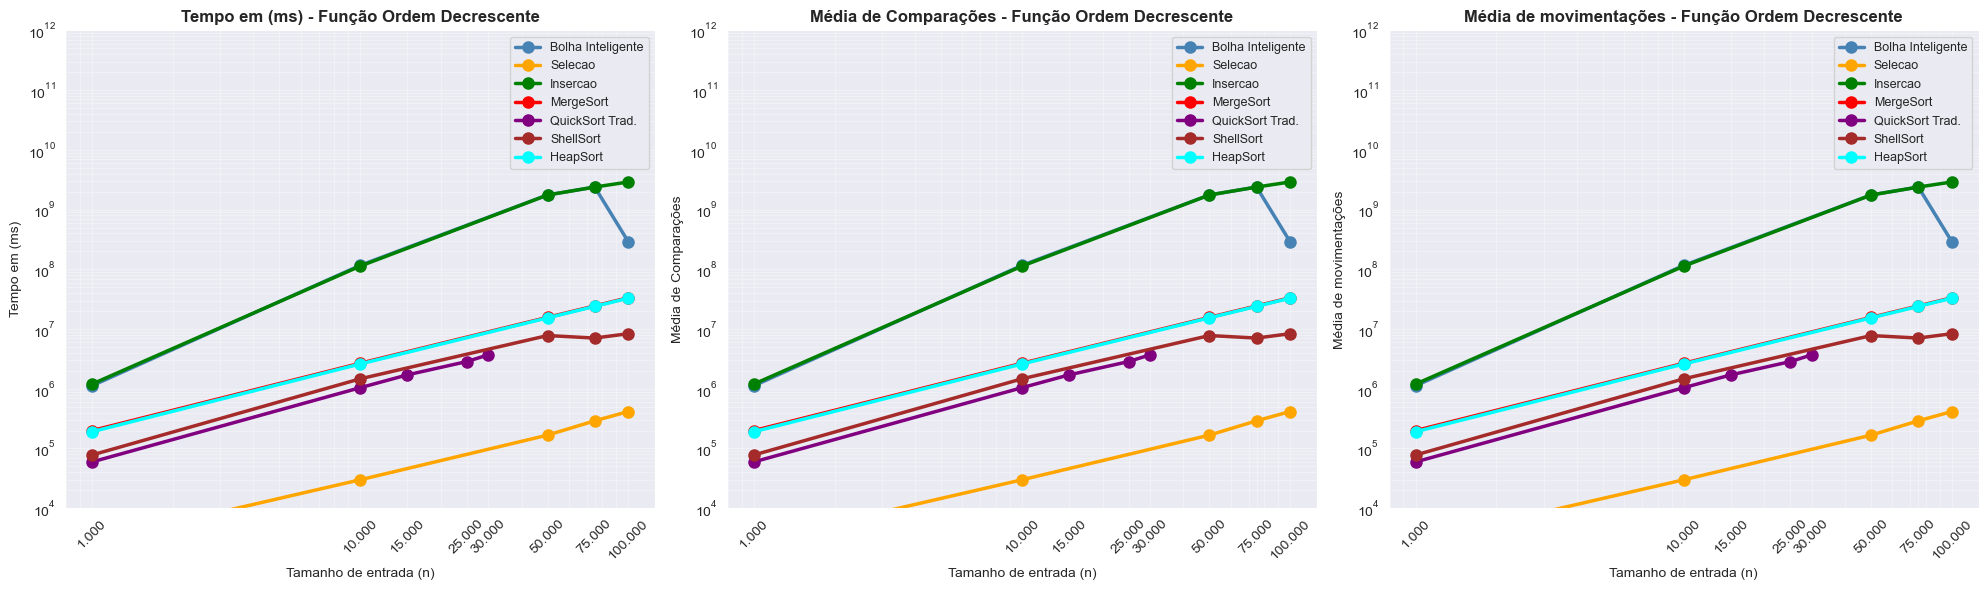

In [ ]:

# Criar 3 subplots: Tempo, Média de Comparações, Média de Movimentações
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Lista de (eixo, título, ylabel)
subplots_config = [
    (axes[0], 'Tempo em (ms)', 'Tempo em (ms)'),
    (axes[1], 'Média de Comparações', 'Média de Comparações'),
    (axes[2], 'Média de movimentações', 'Média de movimentações')
]

# Para cada subplot
for ax, titulo, ylabel in subplots_config:
    ax.plot(x1, y1, marker='o', color='#FF6B6B', linewidth=2.5, markersize=8, label='Bolha Inteligente')
    ax.plot(x2, y2, marker='o', color='#4ECDC4',    linewidth=2.5, markersize=8, label='Selecao')
    ax.plot(x3, y3, marker='o', color='#45B7D1',     linewidth=2.5, markersize=8, label='Insercao')
    ax.plot(x4, y4, marker='o', color='#FFA07A',       linewidth=2.5, markersize=8, label='MergeSort')
    ax.plot(x5, y5, marker='o', color='#98D8C8',    linewidth=2.5, markersize=8, label='QuickSort Trad.')
    ax.plot(x6, y6, marker='o', color='#F7DC6F',     linewidth=2.5, markersize=8, label='ShellSort')
    ax.plot(x7, y7, marker='o', color='#BB8FCE',      linewidth=2.5, markersize=8, label='HeapSort')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e4, 1e12)
    
    ax.set_xticks(todos_x)
    ax.set_xticklabels([f'{int(v):,}'.replace(',', '.') for v in todos_x], rotation=45)
    
    ax.set_title(f'{titulo} - Função Ordem Decrescente', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tamanho de entrada (n)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


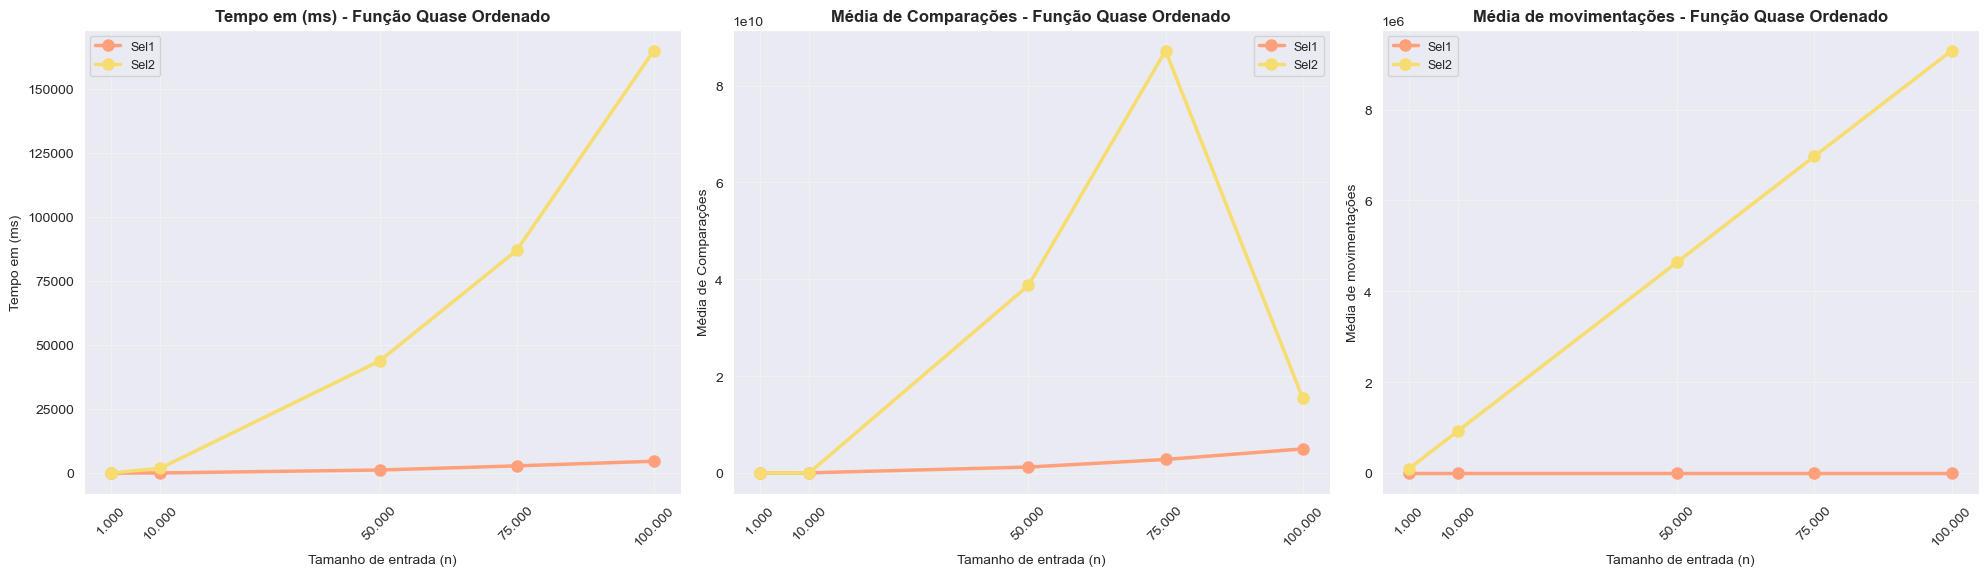

In [12]:

# Criar 3 datasets: um para Tempo, outro para Comparações e outro para Movimentações
# Dataset de Tempo (Temp)
df_tempo = df[['Tamanho de Entrada'] + [col for col in df.columns if col.startswith('Temp')]].copy()

# Dataset de Comparações (Comp)
df_comparacoes = df[['Tamanho de Entrada'] + [col for col in df.columns if col.startswith('Comp')]].copy()

# Dataset de Movimentações (Mov)
df_movimentacoes = df[['Tamanho de Entrada'] + [col for col in df.columns if col.startswith('Mov')]].copy()

# Converter valores dos datasets
df_tempo_conv = df_tempo.copy()
for col in df_tempo_conv.columns:
    if col != 'Tamanho de Entrada':
        df_tempo_conv[col] = parse_br(df_tempo_conv[col])
# Corrigir Tamanho de Entrada dividindo por 10
df_tempo_conv['Tamanho de Entrada'] = df_tempo_conv['Tamanho de Entrada'] 

df_comparacoes_conv = df_comparacoes.copy()
for col in df_comparacoes_conv.columns:
    if col != 'Tamanho de Entrada':
        df_comparacoes_conv[col] = parse_br(df_comparacoes_conv[col])
# Corrigir Tamanho de Entrada dividindo por 10
df_comparacoes_conv['Tamanho de Entrada'] = df_comparacoes_conv['Tamanho de Entrada'] 

df_movimentacoes_conv = df_movimentacoes.copy()
for col in df_movimentacoes_conv.columns:
    if col != 'Tamanho de Entrada':
        df_movimentacoes_conv[col] = parse_br(df_movimentacoes_conv[col])
# Corrigir Tamanho de Entrada dividindo por 10
df_movimentacoes_conv['Tamanho de Entrada'] = df_movimentacoes_conv['Tamanho de Entrada'] 

# Criar figura com 3 subplots para os datasets
sns.set_style('darkgrid')
fig, axes_datasets = plt.subplots(1, 3, figsize=(20, 6))

# Lista com configurações: (dataframe, eixo, título, ylabel)
datasets_config = [
    (df_tempo_conv, axes_datasets[0], 'Tempo em (ms)', 'Tempo em (ms)'),
    (df_comparacoes_conv, axes_datasets[1], 'Média de Comparações', 'Média de Comparações'),
    (df_movimentacoes_conv, axes_datasets[2], 'Média de movimentações', 'Média de movimentações')
]

# Para cada dataset
for idx, (dataset, ax, titulo, ylabel) in enumerate(datasets_config):
    # Extrair colunas numéricas (exceto 'Tamanho de Entrada')
    cols = [col for col in dataset.columns if col != 'Tamanho de Entrada']
    
    # Cores para cada algoritmo
    cores = {'Sel1': '#FFA07A', 'Sel2': '#F7DC6F'}
    
    # Plotar cada coluna
    for col in cols:
        # Remover NaN para este gráfico
        mask = dataset['Tamanho de Entrada'].notna() & dataset[col].notna()
        x_data = dataset.loc[mask, 'Tamanho de Entrada'].values
        y_data = dataset.loc[mask, col].values
        
        # Extrair o nome do algoritmo
        algo_name = col.replace('Temp', '').replace('Comp', '').replace('Mov', '')
        cor = cores.get(algo_name, 'steelblue')
        
        ax.plot(x_data, y_data, marker='o', color=cor, linewidth=2.5, markersize=8, label=algo_name)
        
        # Aplicar escala logarítmica apenas para o segundo e terceiro gráficos (idx > 0)
    
    
    # Obter valores únicos de tamanho (incluindo 1000)
    todos_x_dataset = sorted(set(list(dataset['Tamanho de Entrada'].dropna().unique()) + [1000]))
    ax.set_xticks(todos_x_dataset)
    ax.set_xticklabels([f'{int(v):,}'.replace(',', '.') for v in todos_x_dataset], rotation=45)
    
    ax.set_title(f'{titulo} - Função Quase Ordenado', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tamanho de entrada (n)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
